# Анализ влияния уровня шума на обучение PINN



In [ ]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os
import warnings
from copy import deepcopy
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Импорты — OK')

Импорты — OK


In [ ]:
from pinn_module_final import (
    run_experiment,
    make_consistent_config,
    prepare_config,
    compute_metrics,
    build_solution_grid,
    generate_observations,
    generate_collocation_points,
    generate_boundary_points,
    PINN_Source,
    train_adam,
    train_lbfgs,
    evaluate_model,
    device,
)

print(f'Ядро загружено. Устройство: {device}')

Устройство: cuda
run_experiment — OK
Ядро загружено. Устройство: cuda


In [3]:
import os

OUT_DIR = r"D:\PINN_VKR\noise_analysis"

os.makedirs(OUT_DIR, exist_ok=True)

print("OUT_DIR =", OUT_DIR)

OUT_DIR = D:\PINN_VKR\noise_analysis


In [ ]:
FIXED_EPOCHS   = 15000         
LBFGS_STEPS    = 300           
PRINT_EVERY    = 5_000          
EVAL_EVERY     = 2_500          

NOISE_LEVELS   = [0.0, 0.001, 0.01, 0.03, 0.05, 0.10, 0.15]
NOISE_LABELS   = ['0%', '0.1%', '1%', '3%', '5%', '10%', '15%']

TASK_DEFS = {
    'Тест 1: Heat N+N': dict(
        u_exact       = lambda x, t: np.cos(np.pi * x) * np.exp(-t),
        pde_type      = 'heat',
        pde_kwargs    = {'k': 0.3},
        bc_left_type  = 'neumann',
        bc_right_type = 'neumann',
    ),
    'Тест 2: Heat D+D': dict(
        u_exact       = lambda x, t: np.sin(np.pi * x) * np.cos(2 * np.pi * t),
        pde_type      = 'heat',
        pde_kwargs    = {'k': 0.3},
        bc_left_type  = 'dirichlet',
        bc_right_type = 'dirichlet',
    ),
    'Тест 3: Heat D+N': dict(
        u_exact=lambda x, t: (x**2 + 0.5*x + 1) * np.exp(-t),
        pde_type="heat",
        pde_kwargs={"k": 0.2},
        bc_left_type="dirichlet",
        bc_right_type="neumann",
    ),
    'Тест 5: Diffusion D+D': dict(
        u_exact=lambda x, t: np.sin(2*np.pi*x) * np.cos(np.pi*t) +0.5*x*(1-x),
        pde_type="diffusion",
        pde_kwargs={"D": 0.1},
        bc_left_type="dirichlet",
        bc_right_type="dirichlet",
    ),
    'Тест 8: Advection-Diffusion': dict(
        u_exact=lambda x, t: np.sin(np.pi*x) * np.exp(-t),
        pde_type="advection_diffusion",
        pde_kwargs={"k": 0.05, "v": 0.3},
        bc_left_type="dirichlet",
        bc_right_type="dirichlet",
    )
       
}

TASK_EXTRA = {
    'Тест 1: Heat N+N':                 {},
    'Тест 2: Heat D+D ':                {},
    'Тест 3: Heat D+N':                 {},
    'Тест 5: Diffusion D+D':            {},
    'Тест 8: Advection-Diffusion':  {},
}

TASK_COLORS = {
    'Тест 1: Heat N+N':                    '#1f77b4',
    'Тест 2: Heat D+D':                    '#ff7f0e',
    'Тест 3: Heat D+N':                        '#d62728',
    'Тест 5: Diffusion D+D':               '#603270',
    'Тест 8: Advection-Diffusion':     '#647032',
}

print('Задачи определены:')
for name in TASK_DEFS:
    print(f'  • {name}')
print(f'Уровни шума: {NOISE_LABELS}')
total_runs = len(TASK_DEFS) * len(NOISE_LEVELS)
print(f'Всего запусков: {total_runs}')

Задачи определены:
  • Тест 1: Heat N+N
  • Тест 2: Heat D+D
  • Тест 3: Heat D+N
  • Тест 5: Diffusion D+D
  • Тест 8: Advection-Diffusion
Уровни шума: ['0%', '0.1%', '1%', '3%', '5%', '10%', '15%']
Всего запусков: 35


In [ ]:
def run_noise_experiment(task_name, task_def, extra_kwargs, noise_level, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)

    cfg_raw = make_consistent_config(
        **task_def,
        noise_level  = noise_level,
        epochs       = FIXED_EPOCHS,
        print_every  = PRINT_EVERY,
        eval_every   = EVAL_EVERY,
        **extra_kwargs,
    )
    cfg = prepare_config(cfg_raw)
    trn = cfg['training']
    dom = cfg['domain']


    x_grid, t_grid, U = build_solution_grid(cfg)
    x_obs, t_obs, u_obs = generate_observations(x_grid, t_grid, U, cfg)
    x_col, t_col        = generate_collocation_points(cfg)
    boundary            = generate_boundary_points(cfg)

    data = {
        'x_obs': x_obs, 't_obs': t_obs, 'u_obs': u_obs,
        'x_col': x_col, 't_col': t_col, 'boundary': boundary,
    }


    model = PINN_Source(
        hidden_u   = trn['hidden_layers_u'],
        hidden_f   = trn['hidden_layers_f'],
        activation = trn['activation'],
        x_range    = dom['x_range'],
        t_range    = dom['t_range'],
    ).to(device)

    history, _  = train_adam(model, data, cfg)
    train_lbfgs(model, data, cfg)   

    final_m = evaluate_model(model, cfg, n_eval=80)
    mf = final_m['f']
    mu = final_m['u']

    return {
        'task':         task_name,
        'noise_level':  noise_level,
        'noise_label':  f'{noise_level*100:.1f}%',
        # метрики f
        'f_l2_rel':     mf['l2_rel'],
        'f_h1_rel':     mf['h1_rel'],
        'f_linf':       mf['linf'],
        'f_mae':        mf['mae'],
        'f_rmse':       mf['rmse'],

        # метрики u
        'u_l2_rel':     mu['l2_rel'],
        'u_h1_rel':     mu['h1_rel'],
        'u_linf':       mu['linf'],
        'u_mae':        mu['mae'],
        'u_rmse':       mu['rmse'],

        # дополнительно
        'final_loss':   history['loss'][-1] if history['loss'] else None,
    }

print('run_noise_experiment — OK')

run_noise_experiment — OK


##  Запуск всех экспериментов


In [ ]:
all_results = []

raw_csv = os.path.join(OUT_DIR, 'noise_raw_results.csv')

for task_name, task_def in TASK_DEFS.items():

    extra_kwargs = TASK_EXTRA.get(task_name, {})

    print("\n" + "═" * 90)
    print(f"ЗАДАЧА: {task_name}")
    print("═" * 90)

    for noise_level in NOISE_LEVELS:

        print("\n" + "-" * 90)
        print(f"Запуск: {task_name}, noise = {noise_level*100:.1f}%")
        print("-" * 90)

        result = run_noise_experiment(
            task_name=task_name,
            task_def=task_def,
            extra_kwargs=extra_kwargs,
            noise_level=noise_level,
            seed=SEED,
        )

        all_results.append(result)

        print(
            f"[RESULT] "
            f"noise={noise_level*100:5.1f}% | "
            f"f_L2={result['f_l2_rel']*100:7.3f}% | "
            f"f_H1={result['f_h1_rel']*100:7.3f}% | "
            f"u_L2={result['u_l2_rel']*100:7.3f}% | "
        )

        df = pd.DataFrame(all_results)
        df.to_csv(raw_csv, index=False)

        print(f"✓ Результат сохранён: {raw_csv}")

df = pd.DataFrame(all_results)

print("\nОбучение завершено.")
print(f"Всего строк: {len(df)}")

display(df)


══════════════════════════════════════════════════════════════════════════════════════════
ЗАДАЧА: Тест 1: Heat N+N
══════════════════════════════════════════════════════════════════════════════════════════

------------------------------------------------------------------------------------------
Запуск: Тест 1: Heat N+N, noise = 0.0%
------------------------------------------------------------------------------------------
Прогрев 2000 эпох (subnet_f заморожена). Причина: граничное условие Неймана, сложная/осциллирующая f.
   Эпоха |       Loss |     L_bc_L |     L_bc_R |       L_ic |   u_L2%
-----------------------------------------------------------------
       0 |   8.67e+00 |   9.44e-02 |   9.46e-02 |   6.61e-01 | 108.36%
     500 |   1.80e-02 |   2.29e-04 |   4.68e-04 |   1.11e-03 |   4.77%
    1000 |   3.68e-03 |   7.09e-05 |   6.27e-05 |   2.27e-04 |   2.30%
    1500 |   1.69e-03 |   1.33e-05 |   1.40e-05 |   1.01e-04 |   2.02%
    1999 |   1.55e-03 |   9.74e-06 |   1.33e-05

,task,noise_level,noise_label,f_l2_rel,f_h1_rel,f_linf,f_mae,f_rmse,u_l2_rel,u_h1_rel,u_linf,u_mae,u_rmse,final_loss
0,Тест 1: Heat N+N,0.000,0.0%,0.026841,0.166160,0.148341,0.020572,0.024671,0.000718,0.003377,0.000977,0.000279,0.000337,0.000018
1,Тест 1: Heat N+N,0.001,0.1%,0.028676,0.165563,0.141844,0.022284,0.026358,0.000862,0.003783,0.001352,0.000329,0.000404,0.000038
2,Тест 1: Heat N+N,0.010,1.0%,0.037771,0.219403,0.209885,0.027109,0.034718,0.002516,0.007879,0.004576,0.000874,0.001179,0.000982
3,Тест 1: Heat N+N,0.030,3.0%,0.067619,0.276983,0.365665,0.049250,0.062154,0.007391,0.020569,0.014400,0.002414,0.003464,0.008546
4,Тест 1: Heat N+N,0.050,5.0%,0.139471,0.500718,0.512416,0.105567,0.128199,0.013505,0.039384,0.025614,0.004551,0.006331,0.023675
5,Тест 1: Heat N+N,0.100,10.0%,1.021832,6.141124,2.896031,0.734264,0.939250,0.042561,0.189535,0.070734,0.015671,0.019951,0.094416
6,Тест 1: Heat N+N,0.150,15.0%,2.150140,15.090755,8.072060,1.461939,1.976369,0.072857,0.376213,0.114170,0.026395,0.034153,0.211272
7,Тест 2: Heat D+D,0.000,0.0%,0.017012,0.060406,0.638026,0.032671,0.058477,0.000902,0.003940,0.001941,0.000337,0.000451,0.000333
8,Тест 2: Heat D+D,0.001,0.1%,0.017821,0.061488,0.646378,0.038008,0.061257,0.001071,0.004442,0.002404,0.000422,0.000535,0.000386
9,Тест 2: Heat D+D,0.010,1.0%,0.044792,0.112044,0.790095,0.105463,0.153967,0.004173,0.012738,0.009130,0.001629,0.002087,0.001276


---
##  Сводные таблицы результатов по каждой задаче

In [ ]:
METRICS_F = ['f_l2_rel', 'f_h1_rel', 'f_linf', 'f_mae']
METRICS_U = ['u_l2_rel', 'u_h1_rel', 'u_linf', 'u_mae']

RENAME = {
    'noise_label':  'Шум',
    'f_l2_rel':     'f  L2 rel',
    'f_h1_rel':     'f  H1 rel',
    'f_linf':       'f  L∞',
    'f_mae':        'f  MAE',

    'u_l2_rel':     'u  L2 rel',
    'u_h1_rel':     'u  H1 rel',
    'u_linf':       'u  L∞',
    'u_mae':        'u  MAE',

    'final_loss':   'Final Loss',
}

def pct(x):
    """Форматирование колонок с относительными ошибками как %."""
    return f'{x*100:.4f}%'

for task_name in TASK_DEFS:
    sub = df[df['task'] == task_name].copy()
    display_cols = ['noise_label'] + METRICS_F + METRICS_U + ['final_loss']
    tbl = sub[display_cols].rename(columns=RENAME).reset_index(drop=True)

    for col_orig, col_new in RENAME.items():
        if 'l2' in col_orig or 'h1' in col_orig or 'expl_var' in col_orig:
            if col_new in tbl.columns:
                tbl[col_new] = sub[col_orig].apply(pct).values

    print(f'\n{"═"*80}')
    print(f'  {task_name}')
    print(f'{"═"*80}')
    display(tbl)

    safe_name = task_name.replace(':', '').replace(' ', '_').replace('/', '-')
    tbl.to_csv(os.path.join(OUT_DIR, f'table_{safe_name}.csv'), index=False)
    print(f'  → сохранено: table_{safe_name}.csv')


════════════════════════════════════════════════════════════════════════════════
  Тест 1: Heat N+N
════════════════════════════════════════════════════════════════════════════════


,Шум,f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,0.0%,2.6841%,16.6160%,0.148341,0.020572,0.0718%,0.3377%,0.000977,0.000279,0.000018
1,0.1%,2.8676%,16.5563%,0.141844,0.022284,0.0862%,0.3783%,0.001352,0.000329,0.000038
2,1.0%,3.7771%,21.9403%,0.209885,0.027109,0.2516%,0.7879%,0.004576,0.000874,0.000982
3,3.0%,6.7619%,27.6983%,0.365665,0.049250,0.7391%,2.0569%,0.014400,0.002414,0.008546
4,5.0%,13.9471%,50.0718%,0.512416,0.105567,1.3505%,3.9384%,0.025614,0.004551,0.023675
5,10.0%,102.1832%,614.1124%,2.896031,0.734264,4.2561%,18.9535%,0.070734,0.015671,0.094416
6,15.0%,215.0140%,1509.0755%,8.072060,1.461939,7.2857%,37.6213%,0.114170,0.026395,0.211272


  → сохранено: table_Тест_1_Heat_N+N.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 2: Heat D+D
════════════════════════════════════════════════════════════════════════════════


,Шум,f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,0.0%,1.7012%,6.0406%,0.638026,0.032671,0.0902%,0.3940%,0.001941,0.000337,0.000333
1,0.1%,1.7821%,6.1488%,0.646378,0.038008,0.1071%,0.4442%,0.002404,0.000422,0.000386
2,1.0%,4.4792%,11.2044%,0.790095,0.105463,0.4173%,1.2738%,0.009130,0.001629,0.001276
3,3.0%,15.5515%,38.0809%,3.158659,0.328790,1.3567%,3.9872%,0.025377,0.005080,0.008849
4,5.0%,29.2288%,81.1326%,6.704822,0.617241,2.3106%,7.3117%,0.041558,0.008604,0.023875
5,10.0%,73.7302%,263.0729%,13.937383,1.644955,5.7149%,21.5434%,0.102005,0.021288,0.094037
6,15.0%,117.8533%,452.4414%,23.444750,2.738045,9.0006%,35.4400%,0.157497,0.033618,0.210630


  → сохранено: table_Тест_2_Heat_D+D.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 3: Heat D+N
════════════════════════════════════════════════════════════════════════════════


...

  → сохранено: table_Тест_3_Heat_D+N.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 5: Diffusion D+D
════════════════════════════════════════════════════════════════════════════════


,Шум,f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,0.0%,4.2020%,19.1631%,0.755775,0.048020,0.0975%,0.4831%,0.001617,0.000386,0.000104
1,0.1%,4.5636%,20.2886%,0.803055,0.050330,0.1116%,0.5428%,0.002000,0.000432,0.000108
2,1.0%,6.1185%,23.5521%,1.045522,0.089664,0.4380%,1.3640%,0.010151,0.001742,0.000997
3,3.0%,10.7765%,32.4650%,1.446065,0.175905,1.1063%,2.9047%,0.019556,0.004568,0.008332
4,5.0%,12.6002%,35.6603%,1.649132,0.223190,1.7003%,4.0413%,0.032454,0.006909,0.023098
5,10.0%,62.4139%,254.3914%,6.615300,1.174154,6.3387%,24.0183%,0.152039,0.023711,0.091761
6,15.0%,131.3647%,586.4914%,17.823183,2.429894,10.6767%,44.0526%,0.212053,0.040185,0.204289


  → сохранено: table_Тест_5_Diffusion_D+D.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 8: Advection-Diffusion
════════════════════════════════════════════════════════════════════════════════


,Шум,f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,0.0%,2.2510%,11.1700%,0.073290,0.008421,0.1397%,0.6319%,0.002094,0.000523,0.000009
1,0.1%,1.9809%,9.7038%,0.054049,0.006311,0.0902%,0.4533%,0.001475,0.000329,0.000018
2,1.0%,2.6711%,11.1226%,0.066578,0.010517,0.2596%,0.8149%,0.003494,0.000924,0.000955
3,3.0%,5.8237%,15.5963%,0.107044,0.021963,0.6696%,1.9074%,0.011913,0.002150,0.008518
4,5.0%,12.6592%,33.6097%,0.248782,0.046061,1.3171%,4.3509%,0.027245,0.004280,0.023620
5,10.0%,190.1677%,1501.4695%,5.039375,0.650307,6.6896%,49.4366%,0.127284,0.022741,0.093958
6,15.0%,386.4759%,3635.2510%,10.494787,1.376243,11.2011%,94.9089%,0.205967,0.038606,0.209127


  → сохранено: table_Тест_8_Advection-Diffusion.csv


---
##  Сводный график: все задачи на одном полотне

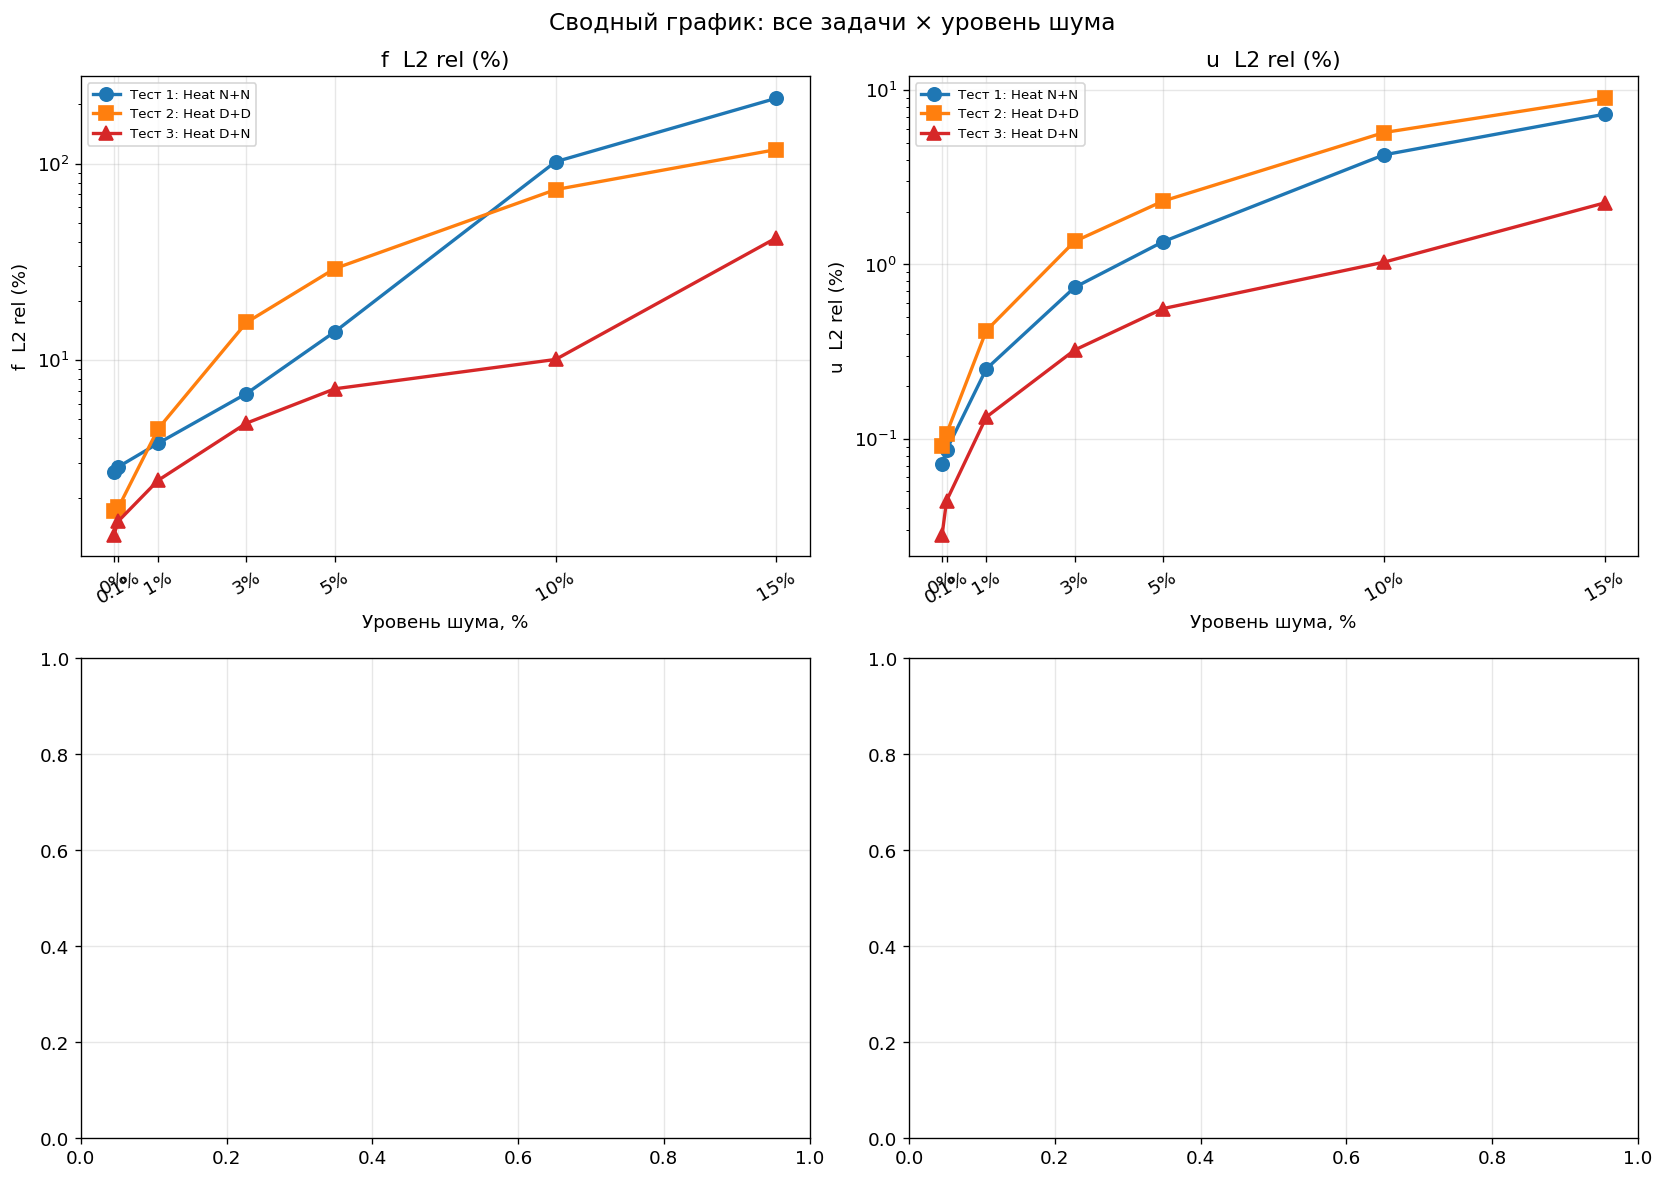

→ сохранено: summary_all_tasks.png


In [9]:
SUMMARY_METRICS = [
    ('f_l2_rel',    'f  L2 rel (%)',   True,  True),
    ('u_l2_rel',    'u  L2 rel (%)',   True,  True),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сводный график: все задачи × уровень шума', fontsize=14)

markers = ['o', 's', '^']

for ax, (col, ylabel, pct_scale, logy) in zip(axes.flat, SUMMARY_METRICS):
    for (task_name, color), marker in zip(TASK_COLORS.items(), markers):
        sub = df[df['task'] == task_name].sort_values('noise_level')
        vals = sub[col].values * (100 if pct_scale else 1)
        ax.plot(noise_x, vals, marker + '-',
                color=color, lw=2, ms=8, label=task_name)

    ax.set_xlabel('Уровень шума, %')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticks(noise_x)
    ax.set_xticklabels(NOISE_LABELS, rotation=30)
    if logy:
        ax.set_yscale('log')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'summary_all_tasks.png'), bbox_inches='tight', dpi=130)
plt.show()
print('→ сохранено: summary_all_tasks.png')

---
## 9. Топ-5 лучших и худших конфигураций → сохранение в CSV

In [ ]:
TOP_METRIC = 'f_l2_rel'  
TOP_N = 5

print(f'Ранжирование по {TOP_METRIC} (меньше = лучше)\n')

display_cols_top = ['task', 'noise_label', 'f_l2_rel', 'f_h1_rel',
                     'u_l2_rel', 'u_h1_rel', 'final_loss']

best_all  = []
worst_all = []

for task_name in TASK_DEFS:
    sub = df[df['task'] == task_name].sort_values(TOP_METRIC)

    best  = sub.head(TOP_N)[display_cols_top].reset_index(drop=True)
    worst = sub.tail(TOP_N).sort_values(TOP_METRIC, ascending=False)[display_cols_top].reset_index(drop=True)


    print(f'{task_name}')
    print(f'  ★ ТОП-{TOP_N} ЛУЧШИХ (наименьший f_L2):')
    display(best)
    print(f'  ✗ ТОП-{TOP_N} ХУДШИХ (наибольший f_L2):')
    display(worst)

    best_all.append(best)
    worst_all.append(worst)

df_best  = pd.concat(best_all,  ignore_index=True)
df_worst = pd.concat(worst_all, ignore_index=True)

df_best.to_csv(os.path.join(OUT_DIR,  'top5_best.csv'),  index=False)
df_worst.to_csv(os.path.join(OUT_DIR, 'top5_worst.csv'), index=False)
print('\n✓ Файлы сохранены: top5_best.csv  /  top5_worst.csv')

Ранжирование по f_l2_rel (меньше = лучше)

Тест 1: Heat N+N
  ★ ТОП-5 ЛУЧШИХ (наименьший f_L2):


,task,noise_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 1: Heat N+N,0.0%,0.026841,0.166160,0.000718,0.003377,0.000018
1,Тест 1: Heat N+N,0.1%,0.028676,0.165563,0.000862,0.003783,0.000038
2,Тест 1: Heat N+N,1.0%,0.037771,0.219403,0.002516,0.007879,0.000982
3,Тест 1: Heat N+N,3.0%,0.067619,0.276983,0.007391,0.020569,0.008546
4,Тест 1: Heat N+N,5.0%,0.139471,0.500718,0.013505,0.039384,0.023675


  ✗ ТОП-5 ХУДШИХ (наибольший f_L2):


,task,noise_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 1: Heat N+N,15.0%,2.150140,15.090755,0.072857,0.376213,0.211272
1,Тест 1: Heat N+N,10.0%,1.021832,6.141124,0.042561,0.189535,0.094416
2,Тест 1: Heat N+N,5.0%,0.139471,0.500718,0.013505,0.039384,0.023675
3,Тест 1: Heat N+N,3.0%,0.067619,0.276983,0.007391,0.020569,0.008546
4,Тест 1: Heat N+N,1.0%,0.037771,0.219403,0.002516,0.007879,0.000982


Тест 2: Heat D+D
  ★ ТОП-5 ЛУЧШИХ (наименьший f_L2):


...

Тест 8: Advection-Diffusion
  ★ ТОП-5 ЛУЧШИХ (наименьший f_L2):


,task,noise_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 8: Advection-Diffusion,0.1%,0.019809,0.097038,0.000902,0.004533,0.000018
1,Тест 8: Advection-Diffusion,0.0%,0.022510,0.111700,0.001397,0.006319,0.000009
2,Тест 8: Advection-Diffusion,1.0%,0.026711,0.111226,0.002596,0.008149,0.000955
3,Тест 8: Advection-Diffusion,3.0%,0.058237,0.155963,0.006696,0.019074,0.008518
4,Тест 8: Advection-Diffusion,5.0%,0.126592,0.336097,0.013171,0.043509,0.023620


  ✗ ТОП-5 ХУДШИХ (наибольший f_L2):


,task,noise_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 8: Advection-Diffusion,15.0%,3.864759,36.352510,0.112011,0.949089,0.209127
1,Тест 8: Advection-Diffusion,10.0%,1.901677,15.014695,0.066896,0.494366,0.093958
2,Тест 8: Advection-Diffusion,5.0%,0.126592,0.336097,0.013171,0.043509,0.023620
3,Тест 8: Advection-Diffusion,3.0%,0.058237,0.155963,0.006696,0.019074,0.008518
4,Тест 8: Advection-Diffusion,1.0%,0.026711,0.111226,0.002596,0.008149,0.000955



✓ Файлы сохранены: top5_best.csv  /  top5_worst.csv


---
##  Барчарты f_L2 по уровню шума и задаче

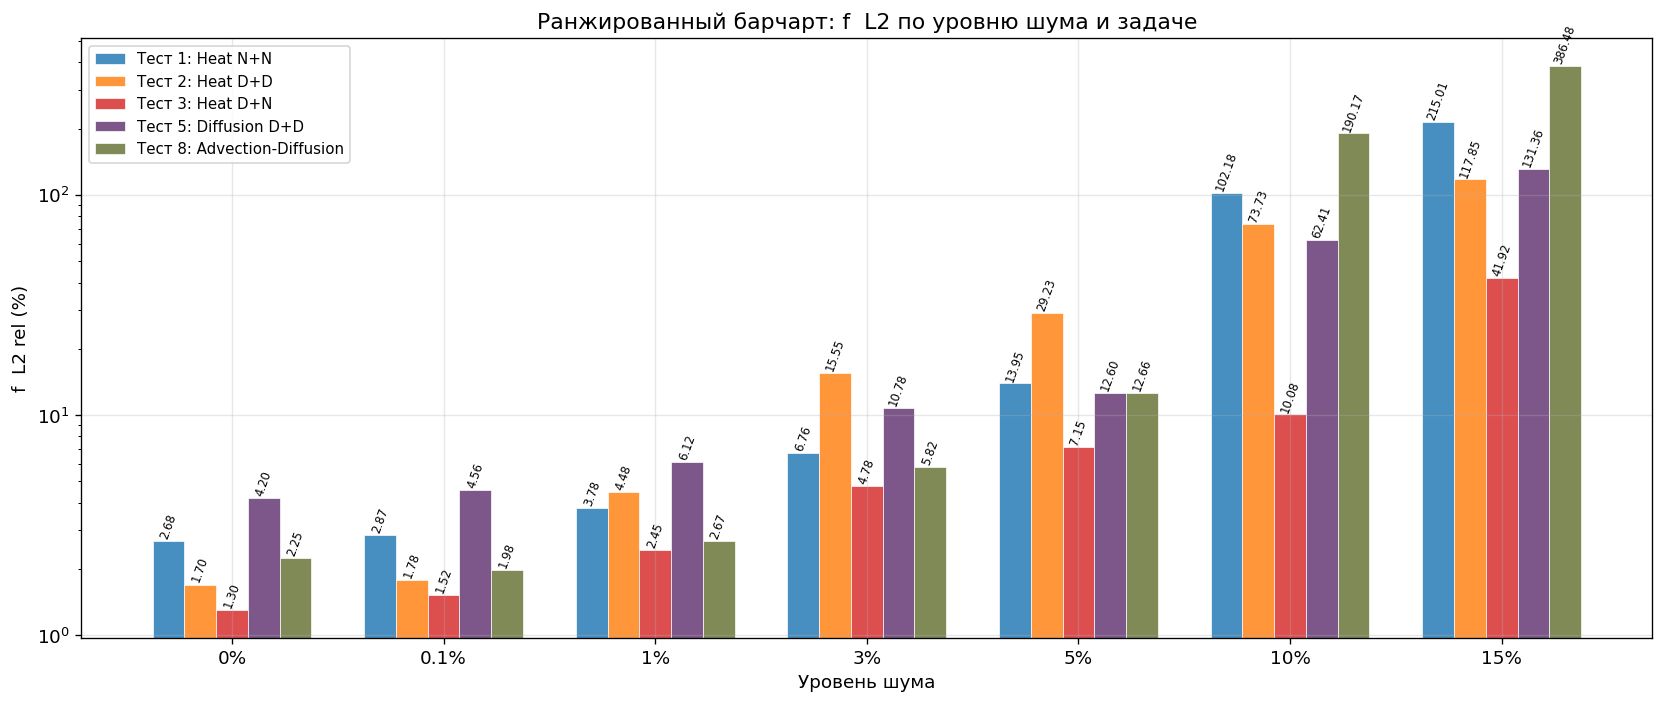

→ сохранено: barchart_f_l2.png


In [ ]:
task_names = list(TASK_DEFS.keys())
n_tasks  = len(task_names)
n_noise  = len(NOISE_LEVELS)
bar_x    = np.arange(n_noise)
bar_w    = 0.15
offsets  = (np.arange(n_tasks) - (n_tasks - 1) / 2) * bar_w

fig, ax = plt.subplots(figsize=(14, 6))

for i, (task_name, color) in enumerate(TASK_COLORS.items()):
    sub  = df[df['task'] == task_name].sort_values('noise_level')
    vals = sub['f_l2_rel'].values * 100
    bars = ax.bar(bar_x + offsets[i], vals, bar_w,
                  label=task_name, color=color, alpha=0.82, edgecolor='white', lw=0.5)
    for bar, v in zip(bars, vals):
        if v < max(vals) * 1.5:   
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7, rotation=70)

ax.set_xticks(bar_x)
ax.set_xticklabels(NOISE_LABELS)
ax.set_xlabel('Уровень шума')
ax.set_ylabel('f  L2 rel (%)')
ax.set_title('Ранжированный барчарт: f  L2 по уровню шума и задаче')
ax.set_yscale('log')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'barchart_f_l2.png'), bbox_inches='tight', dpi=130)
plt.show()
print('→ сохранено: barchart_f_l2.png')

---
## Финальная сводная таблица



In [ ]:
summary_cols = ['task', 'noise_label', 'f_l2_rel', 'f_h1_rel',
                'u_l2_rel', 'u_h1_rel', 'final_loss']
df_summary = df[summary_cols].copy()

for c in ['f_l2_rel', 'f_h1_rel', 'u_l2_rel', 'u_h1_rel']:
    df_summary[c] = (df_summary[c] * 100).round(4).astype(str) + '%'

df_summary['final_loss'] = df_summary['final_loss'].apply(lambda x: f'{x:.3e}' if x else 'N/A')
df_summary = df_summary.rename(columns=RENAME)
df_summary.to_csv(os.path.join(OUT_DIR, 'final_summary.csv'), index=False)

display(df_summary)
print('\n✓ Итоговая таблица сохранена → final_summary.csv')
print(f'Все файлы в папке: {OUT_DIR}')

,task,Шум,f L2 rel,f H1 rel,u L2 rel,u H1 rel,Final Loss
0,Тест 1: Heat N+N,0.0%,2.6841%,16.616%,0.0718%,0.3377%,1.808e-05
1,Тест 1: Heat N+N,0.1%,2.8676%,16.5563%,0.0862%,0.3783%,3.752e-05
2,Тест 1: Heat N+N,1.0%,3.7771%,21.9403%,0.2516%,0.7879%,9.815e-04
3,Тест 1: Heat N+N,3.0%,6.7619%,27.6983%,0.7391%,2.0569%,8.546e-03
4,Тест 1: Heat N+N,5.0%,13.9471%,50.0718%,1.3505%,3.9384%,2.368e-02
5,Тест 1: Heat N+N,10.0%,102.1832%,614.1124%,4.2561%,18.9535%,9.442e-02
6,Тест 1: Heat N+N,15.0%,215.014%,1509.0755%,7.2857%,37.6213%,2.113e-01
7,Тест 2: Heat D+D,0.0%,1.7012%,6.0406%,0.0902%,0.394%,3.327e-04
8,Тест 2: Heat D+D,0.1%,1.7821%,6.1488%,0.1071%,0.4442%,3.864e-04
9,Тест 2: Heat D+D,1.0%,4.4792%,11.2044%,0.4173%,1.2738%,1.276e-03



✓ Итоговая таблица сохранена → final_summary.csv
Все файлы в папке: D:\PINN_VKR\noise_analysis
